In [1]:
import os
import csv
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data preprocessing

The structure of the `csv` is as follows:

|workload|AQM|AVG|Small|Small (99$^{\text{th}}$ Percentile)|Large|Load|
|--------|---|---|-----|-----------------------------------|-----|----|
|dc/web  |red/ecnsharp/norm|float|float|float|float|$[0.2, \; 0.9]$|

In [2]:
data = pd.read_csv("data-f13_14.csv")

In [3]:
data = data[data["aqm"] == "norm"]
data_dc = data[data["workload"] == "dc"].drop(columns=["workload"])
data8x8_dc = data_dc[data_dc["topology"] == "8x8"].drop(columns=["topology"])
data4x4_dc = data_dc[data_dc["topology"] == "4x4"].drop(columns=["topology"])

data_web = data[data["workload"] == "web"].drop(columns=["workload"])
data8x8_web = data_web[data_web["topology"] == "8x8"].drop(columns=["topology"])
data4x4_web = data_web[data_web["topology"] == "4x4"].drop(columns=["topology"])

## Figures

The two topologies used are indicated with the scheme `<ServersPerLeaf>x<LeafSwitches>x<SpineSwitches>`. Such topologies are the following:

- one that resembles the large scale topology mentioned in the paper (16 servers per leaf switch, 8 leaf switches and 8 spine switches). It's denoted as `16x8x8`;
- one that takes the standard parameters mentioned in the GitHub repo (8 servers per leaf switch, 4 leaf switches and 4 spine switches). It's denoted as `8x4x4`.

### Figure 13 (Web workload)

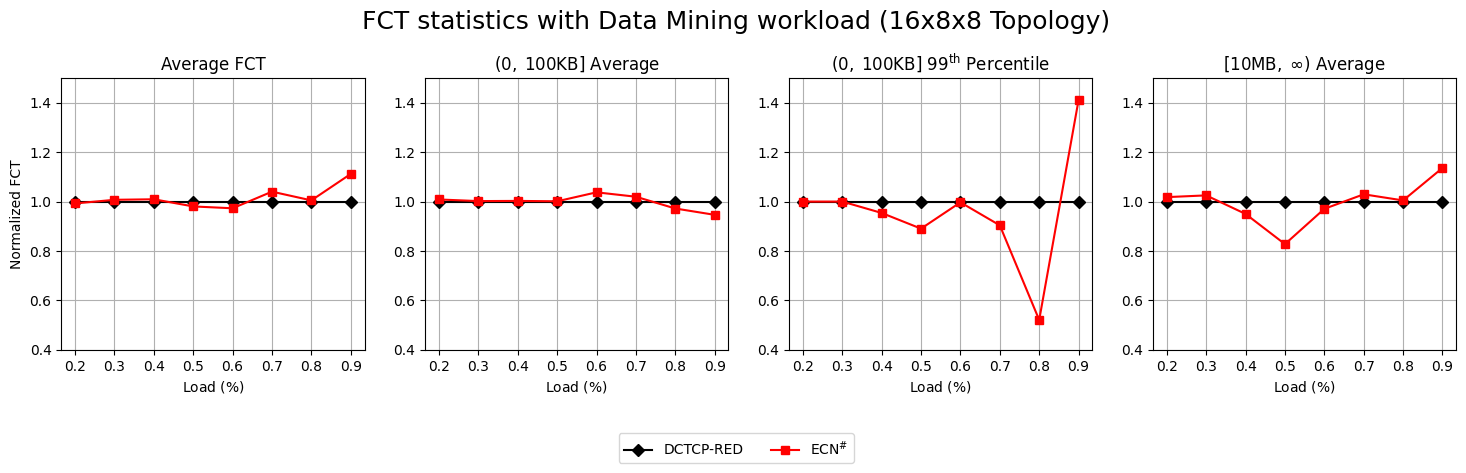

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data8x8_web
headers = list(norm_data.columns.values)[2:]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.4, 1.5)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (16x8x8 Topology)", y=1.05, fontsize=18)

fig.savefig("figure13_16x8x8.png", transparent=True)

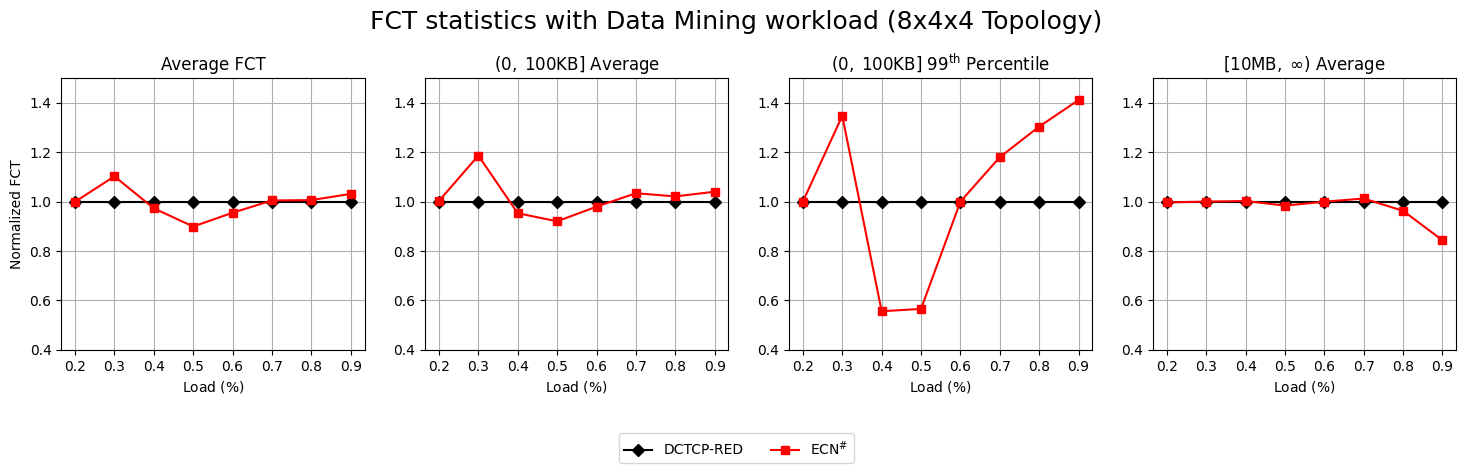

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data4x4_web
headers = list(norm_data.columns.values)[2:]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.4, 1.5)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (8x4x4 Topology)", y=1.05, fontsize=18)

fig.savefig("figure13_8x4x4.png", transparent=True)

### Figure 14 (Data Mining workload)

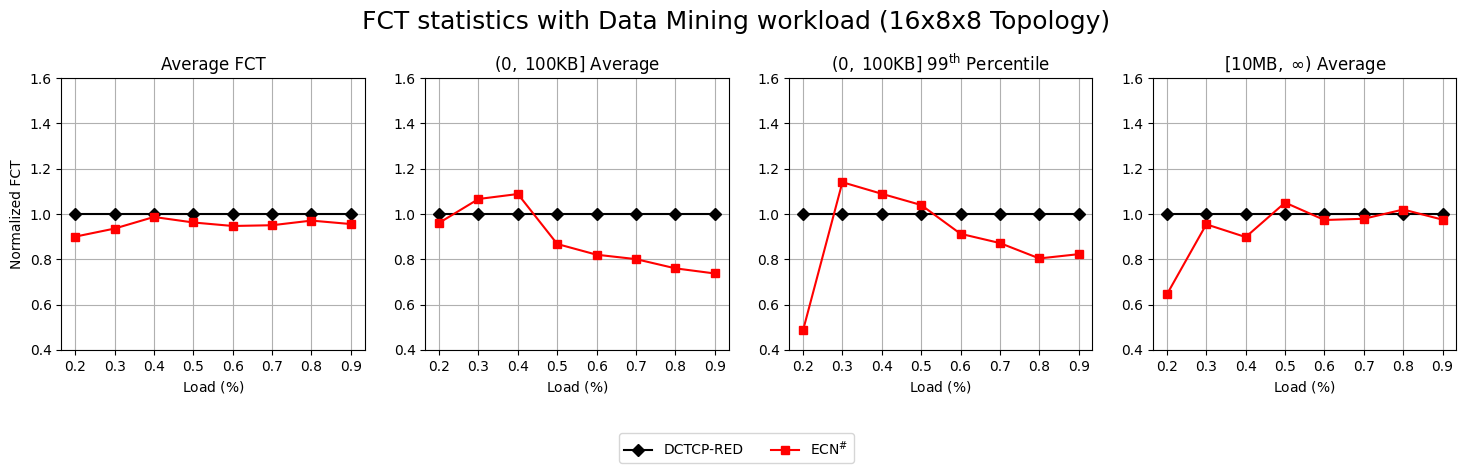

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data8x8_dc
headers = list(norm_data.columns.values)[2:]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.4, 1.6)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (16x8x8 Topology)", y=1.05, fontsize=18)

fig.savefig("figure14_16x8x8.png", transparent=True)

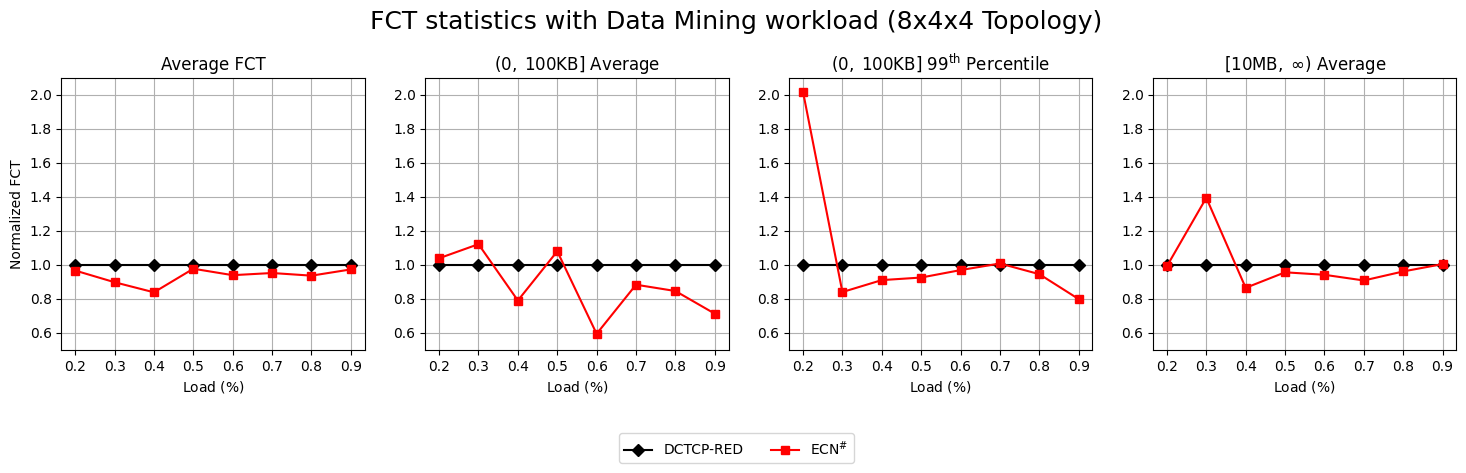

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

interval = [_/10 for _ in range(2, 10)]
norm_data = data4x4_dc
headers = list(norm_data.columns.values)[2:]
headers_labels = ["Average FCT", "$(0, \\; 100\\text{KB}]$ Average", "$(0, \\; 100\\text{KB}]$ 99$^{\\text{th}}$ Percentile", "$[10\\text{MB}, \\; \\infty)$ Average"]

for i, ax in enumerate(axes):
    ax.plot(interval, [1 for _ in interval], marker="D", color="black", label="DCTCP-RED")
    ax.plot(norm_data["load"], norm_data[headers[i]], marker="s", color="red", label="ECN$^\\#$")
    ax.set_ylim(0.5, 2.1)
    ax.set_title(headers_labels[i])
    ax.set_xlabel("Load ($\\%$)")
    ax.set_xticks(interval)
    ax.grid()

    if i == 0:
        ax.set_ylabel("Normalized FCT")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=len(labels), frameon=True)
fig.subplots_adjust(bottom=0.2)
fig.suptitle("FCT statistics with Data Mining workload (8x4x4 Topology)", y=1.05, fontsize=18)

fig.savefig("figure14_8x4x4.png", transparent=True)